# Regresión Logística — Clasificación Binaria de Popularidad de Videojuegos

## 📊 Descripción General

Este notebook entrena un **LogisticRegression** para predecir si un videojuego será **popular** (muchas reseñas de usuarios) o **nicho** (pocas reseñas), basado en características multidimensionales.

**Variable objetivo:** Popularidad binaria (Ratings_Count ≥ mediana)

**Predictores (6 variables numéricas escaladas):**
1. `Rating` — Puntuación promedio de usuarios
2. `Metacritic` — Puntuación de crítica profesional
3. `Playtime` — Horas promedio de juego
4. `Edad_Juego` — Años desde lanzamiento
5. `Num_Platforms` — Número de plataformas disponibles
6. `Num_Genres` — Cantidad de géneros

**Modelo:** Regresión Logística con balanceo automático de clases (`class_weight='balanced'`)

---

### 🎯 Diferencia con Árbol de Decisión (CART)

| Aspecto | Árbol CART | Regresión Logística |
|--------|-----------|-------------------|
| **Tipo** | Árbol de decisión no paramétrico | Modelo lineal probabilístico |
| **Escalado** | No requiere | ✅ SÍ (StandardScaler) |
| **Interpretabilidad** | Muy alta (decisiones binarias) | Media (coeficientes lineales) |
| **Complejidad** | Control con `max_depth` | Regulación L2 automática |
| **Velocidad** | Rápida | Muy rápida |
| **Balanceo** | `class_weight='balanced'` + Oversampling | `class_weight='balanced'` |

In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"    pandas   {pd.__version__}")
print(f"    numpy    {np.__version__}")
print(f"    seaborn  {sns.__version__}")

✅ Librerías importadas correctamente
    pandas   2.2.2
    numpy    1.26.4
    seaborn  0.13.2


In [2]:
# ── CELDA 2: Extracción SQL ───────────────────────────────────────────────────
# Basado en la estructura de videojuegos_top
SQL_QUERY = """
SELECT 
    nombre, 
    rating, 
    metacritic, 
    ratings_count, 
    added, 
    playtime, 
    fecha_lanzamiento, 
    platforms, 
    genres, 
    esrb_rating
FROM videojuegos_top
ORDER BY fecha_lanzamiento;
"""

with engine.connect() as conn:
    df_videojuegos = pd.read_sql(text(SQL_QUERY), conn)

# Definición de la variable objetivo: Popularidad (Basada en la mediana de ratings_count)
umbral_popularidad = df_videojuegos['ratings_count'].median()
df_videojuegos['es_popular'] = (df_videojuegos['ratings_count'] >= umbral_popularidad).astype(int)

print(f"✅ Datos cargados: {df_videojuegos.shape[0]:,} filas × {df_videojuegos.shape[1]} columnas")
print(f"\nBalance de la variable objetivo (Popularidad >= {umbral_popularidad} reseñas):")
bal = df_videojuegos['es_popular'].value_counts()
pct = df_videojuegos['es_popular'].value_counts(normalize=True) * 100
print(f"    Popular (1): {bal[1]:,}  ({pct[1]:.1f}%)")
print(f"    De Nicho (0): {bal[0]:,}  ({pct[0]:.1f}%)")
df_videojuegos.head()

✅ Datos cargados: 113 filas × 11 columnas

Balance de la variable objetivo (Popularidad >= 2293.0 reseñas):
    Popular (1): 57  (50.4%)
    De Nicho (0): 56  (49.6%)


,nombre,rating,metacritic,ratings_count,added,playtime,fecha_lanzamiento,platforms,genres,esrb_rating,es_popular
0,Half-Life,4.37,96.0,2446,11535,3,1998-11-19,"[""Linux"", ""macOS"", ""PC"", ""Dreamcast"", ""PlaySta...","[""Action"", ""Shooter""]",Mature,1
1,Counter-Strike,4.06,88.0,1655,9325,3,2000-11-01,"[""Xbox"", ""Linux"", ""macOS"", ""PC""]","[""Action"", ""Shooter""]",None,0
2,Grand Theft Auto: Vice City,4.44,94.0,3104,9908,2,2002-10-27,"[""Android"", ""macOS"", ""PC"", ""iOS"", ""PlayStation...","[""Action""]",Mature,1
3,Grand Theft Auto: San Andreas,4.50,93.0,4064,12134,2,2004-10-26,"[""macOS"", ""PC"", ""iOS"", ""Xbox"", ""Android"", ""Pla...","[""Action""]",Mature,1
4,Counter-Strike: Source,3.75,88.0,1530,9549,7,2004-11-01,"[""Linux"", ""macOS"", ""PC""]","[""Shooter""]",Mature,0


## 📋 Exploración del Dataset

Después de cargar los datos, verificamos:
- **Dimensiones**: Número de filas y columnas
- **Balance de clases**: ¿Hay más juegos nicho que populares?
- **Tipos de datos**: ¿Todas las variables son numéricas o hay strings?
- **Valores nulos**: ¿Qué columnas tienen datos faltantes?
- **Variable objetivo**: Popularidad = Ratings_Count ≥ mediana

La mediana de ratings_count es el **umbral de decisión**: juegos con más reseñas que esto se clasifican como populares.

In [3]:
# ── CELDA 3: Validación y Exploración ────────────────────────────────────────
print("=" * 55)
print("VALIDACIÓN DEL DATASET DE VIDEOJUEGOS")
print("=" * 55)

# Tipos y nulos
print("\n📋 Tipos de datos y valores nulos:")
print(df_videojuegos.dtypes.to_frame('dtype').join(
    df_videojuegos.isnull().sum().to_frame('nulos')
))

# Estadísticas de variables clave
print(f"\n🎯 Estadísticas de Rating y Metacritic:")
print(df_videojuegos[['rating', 'metacritic']].describe().round(2))

# Conteo de nulos específicos
nulos_meta = df_videojuegos['metacritic'].isnull().sum()
print(f"\n⚠️ Registros sin Metacritic: {nulos_meta} (serán eliminados en preprocesamiento)")

VALIDACIÓN DEL DATASET DE VIDEOJUEGOS

📋 Tipos de datos y valores nulos:
                     dtype  nulos
nombre              object      0
rating             float64      0
metacritic         float64      0
ratings_count        int64      0
added                int64      0
playtime             int64      0
fecha_lanzamiento   object      0
platforms           object      0
genres              object      0
esrb_rating         object     16
es_popular           int64      0

🎯 Estadísticas de Rating y Metacritic:
       rating  metacritic
count  113.00      113.00
mean     4.09       85.47
std      0.37        6.00
min      3.07       70.00
25%      3.91       81.00
50%      4.14       86.00
75%      4.38       90.00
max      4.69       96.00

⚠️ Registros sin Metacritic: 0 (serán eliminados en preprocesamiento)


In [4]:
# ── CELDA 4: Preprocesamiento ─────────────────────────────────────────────────
df = df_videojuegos.copy()

# 4.1 Ingeniería de variables (Fechas y conteos de listas)
df['fecha_lanzamiento'] = pd.to_datetime(df['fecha_lanzamiento'], errors='coerce')
df['edad_juego'] = 2024 - df['fecha_lanzamiento'].dt.year

def count_items(x):
    if isinstance(x, str):
        try: return len(json.loads(x.replace("'", '"')))
        except: return 0
    return len(x) if x is not None else 0

df['num_platforms'] = df['platforms'].apply(count_items)
df['num_genres'] = df['genres'].apply(count_items)

# 4.2 Limpieza de nulos
df = df.dropna(subset=['metacritic', 'rating', 'edad_juego'])

# 4.3 Columnas numéricas a escalar
num_cols = ['rating', 'metacritic', 'playtime', 'edad_juego', 'num_platforms', 'num_genres']

# 4.4 Definir X e y
X_raw = df[num_cols]
y = df['es_popular']

# 4.5 Escalar datos
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=num_cols)

print(f"✅ Preprocesamiento completado")
print(f"    Shape X: {X_scaled.shape}")
print(f"    Variables predictoras: {X_scaled.columns.tolist()}")
print(f"\n    Clases finales en y → Nicho (0): {(y==0).sum():,} | Popular (1): {(y==1).sum():,}")

✅ Preprocesamiento completado
    Shape X: (113, 6)
    Variables predictoras: ['rating', 'metacritic', 'playtime', 'edad_juego', 'num_platforms', 'num_genres']

    Clases finales en y → Nicho (0): 56 | Popular (1): 57


## 📐 Técnica de Balanceo: Class Weight (Regresión Logística)

### ¿Por qué hay desbalance de clases?

El dataset tiene más videojuegos "nicho" que "populares". Sin técnicas de balanceo, la regresión logística aprende a clasificar todo como nicho porque maximiza la exactitud general.

### Solución: `class_weight='balanced'` en LogisticRegression

A diferencia del árbol CART que usa **oversampling**:
- Regresión Logística ajusta **automáticamente los pesos de cada clase** en la función de pérdida
- Penaliza más los errores en la clase minoritaria (popular)
- **Sin modificar los datos** → sin data leakage
- **Más eficiente** computacionalmente que el oversampling

### Flujo implementado:
```
1. train_test_split (estratificado) → mantiene balance original
2. StandardScaler → escala características (requerido para LogisticRegression)
3. LogisticRegression(class_weight='balanced') → entrena con pesos ajustados
4. Evalúa en test set original (sin cambios)
```

✅ **Ventajas de este enfoque:**
- Recall mejorado en clase minoritaria (detecta mejor juegos populares)
- Conserva el balance original del test set (evaluación justa)
- Computacionalmente eficiente
- Interpretable: coeficientes indican impacto de cada variable

In [5]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────────────────────
def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split"):
    """
    Entrena LogisticRegression con un split específico y devuelve métricas detalladas.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    modelo = LogisticRegression(
        max_iter=1000,
        random_state=random_state,
        class_weight='balanced' # Ajuste automático para balanceo de clases
    )
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    metricas = {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'modelo'    : modelo,
    }
    return metricas

print("✅ Función `entrenar_evaluar` adaptada para clasificación de videojuegos")

✅ Función `entrenar_evaluar` adaptada para clasificación de videojuegos


In [6]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────────────────────
resultados = [
    entrenar_evaluar(X_scaled, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X_scaled, y, test_size=0.40, nombre="Split 60/40"),
    entrenar_evaluar(X_scaled, y, test_size=0.30, nombre="Split 70/30"),
]

# ── Imprimir métricas en consola ──────────────────────────────────────────────
print("=" * 65)
print(f"{'MÉTRICAS COMPARATIVAS — CLASIFICACIÓN DE POPULARIDAD':^65}")
print("=" * 65)
header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 65)
for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )
print("=" * 65)

      MÉTRICAS COMPARATIVAS — CLASIFICACIÓN DE POPULARIDAD       
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20        90       23  0.7826  0.7692  0.8333  0.8000  0.7273
Split 60/40        67       46  0.7174  0.7273  0.6957  0.7111  0.7826
Split 70/30        79       34  0.7647  0.7368  0.8235  0.7778  0.7682


## 📈 Visualización de Resultados

Las siguientes celdas generan:

1. **Curvas ROC**: Compara desempeño de los 3 splits (mayor AUC = mejor discriminación)
2. **Matrices de Confusión**: Detalla True/False Positives/Negatives para cada split
3. **Comparativa de Métricas**: Gráfico de barras con todas las métricas
4. **Impacto de Variables**: Coeficientes del modelo (qué factores impulsan popularidad)

## 🎯 Entrenamiento y Evaluación del Modelo

### Estrategia de validación:

Usamos **3 divisiones train/test diferentes** para evaluar robustez:
- **Split 80/20**: 80% entrenamiento, 20% prueba (más datos para entrenar)
- **Split 60/40**: 60% entrenamiento, 40% prueba (validación más rigurosa)
- **Split 70/30**: 70% entrenamiento, 30% prueba (balance intermedio)

Si las métricas son **consistentes entre splits**, el modelo generaliza bien. Si varían mucho, hay problemas de estabilidad.

### Métricas principales:

- **Accuracy**: % de predicciones correctas (cuidado: puede ser alto con desbalance)
- **Precision**: De los predichos como populares, ¿cuántos realmente lo son?
- **Recall**: ¿Qué % de juegos populares detectamos correctamente?
- **F1-Score**: Media armónica de Precision y Recall
- **ROC-AUC**: Área bajo la curva ROC (capacidad discriminativa: 0.5=aleatorio, 1.0=perfecto)

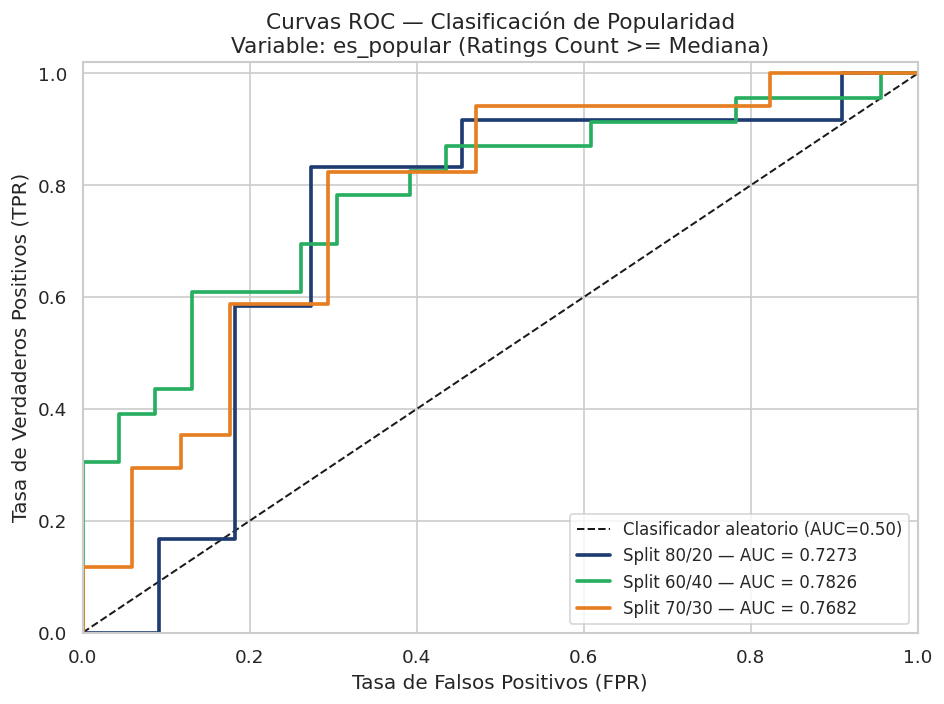

✅ Curvas ROC guardadas


In [7]:
# ── CELDA 7: Curvas ROC comparativas ─────────────────────────────────────────
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

for r, color in zip(resultados, COLORS):
    ax.plot(
        r['fpr'], r['tpr'], color=color, lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Clasificación de Popularidad\nVariable: es_popular (Ratings Count >= Mediana)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('../data/graficas/roc_logistica_videojuegos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Curvas ROC guardadas")

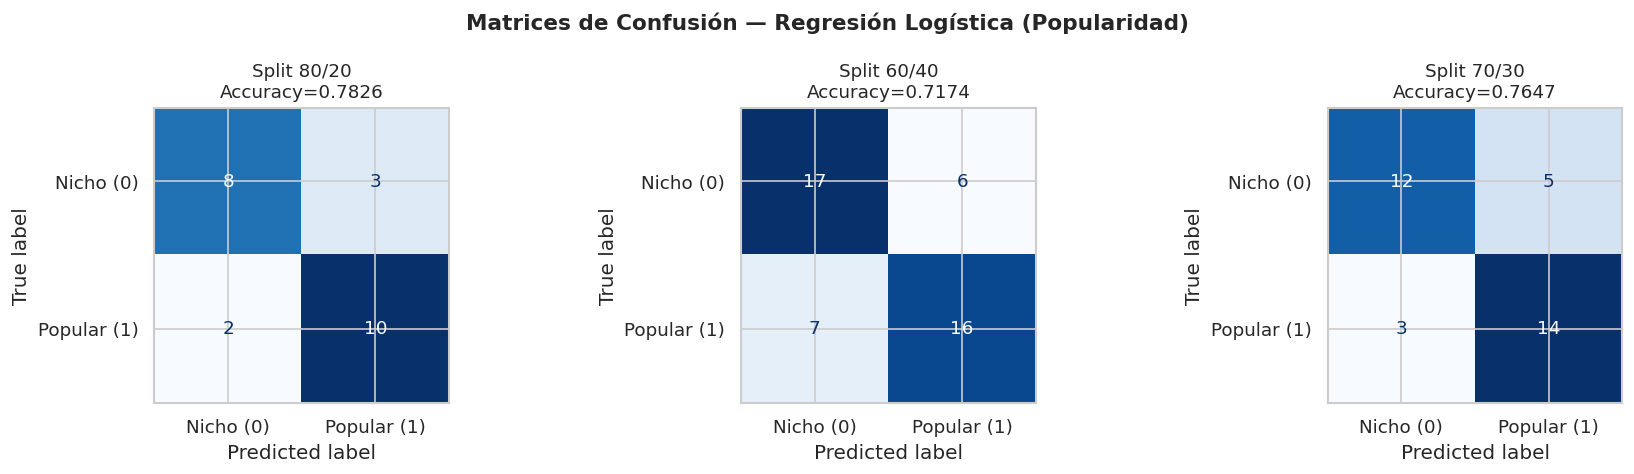

In [8]:
# ── CELDA 8: Matrices de Confusión (3 splits) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — Regresión Logística (Popularidad)', fontsize=13, fontweight='bold')

for ax, r, color in zip(axes, resultados, COLORS):
    cm  = confusion_matrix(r['y_test'], r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Nicho (0)', 'Popular (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}", fontsize=11)

plt.tight_layout()
plt.savefig('../data/graficas/confusion_logistica_videojuegos.png', dpi=150, bbox_inches='tight')
plt.show()

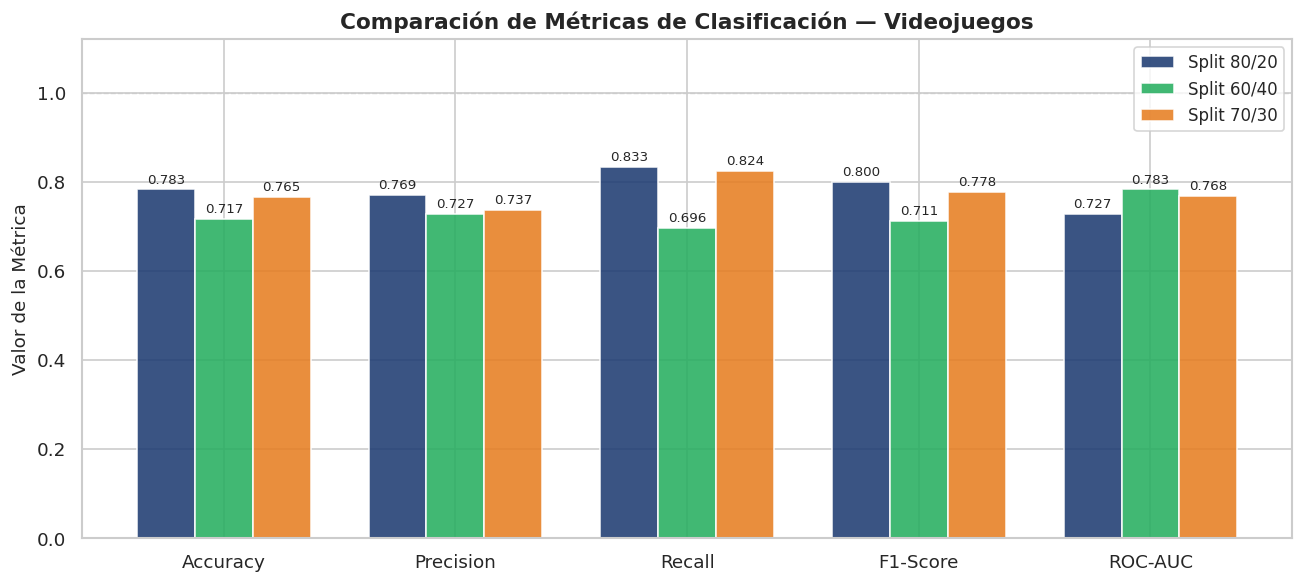

In [9]:
# ── CELDA 9: Gráfico comparativo de métricas ─────────────────────────────────
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas        = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x     = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]
    bars = ax.bar(x + i * width, vals, width, label=r['nombre'], color=color, alpha=0.88)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Comparación de Métricas de Clasificación — Videojuegos', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=1.0, color='#ccc', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('../data/graficas/metricas_comparativas_videojuegos.png', dpi=150, bbox_inches='tight')
plt.show()

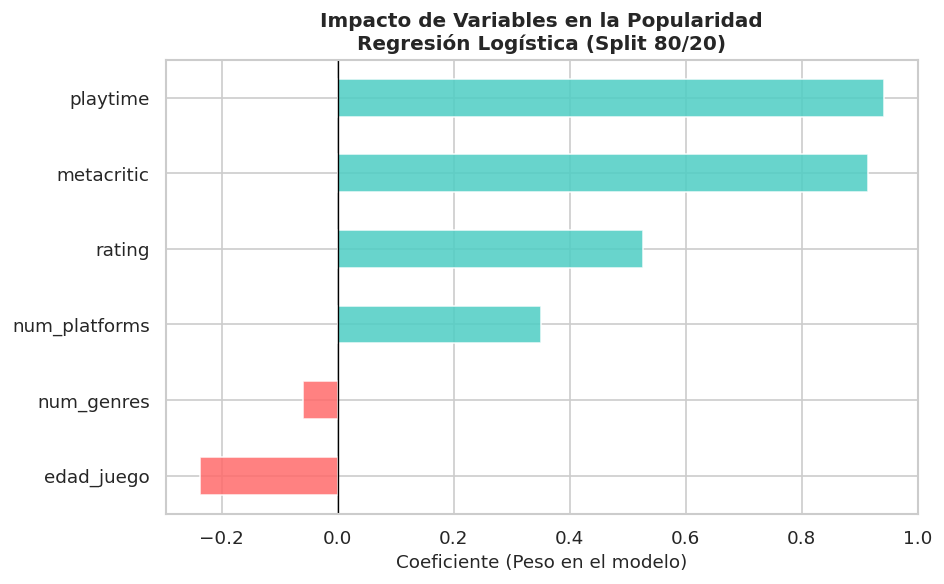

✅ Importancia de variables analizada. (Verde: Aumenta popularidad | Rojo: Disminuye)


In [10]:
# ── CELDA 10: Importancia de coeficientes (Split 80/20) ──────────────────────
modelo_ref = resultados[0]['modelo']
coefs      = pd.Series(modelo_ref.coef_[0], index=X_scaled.columns)
coefs_ord  = coefs.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
# Usamos colores para distinguir efectos positivos/negativos
colores_impacto = ['#ff6b6b' if x < 0 else '#4ecdc4' for x in coefs_ord.values]
coefs_ord.plot(kind='barh', ax=ax, color=colores_impacto, alpha=0.85)

ax.set_xlabel('Coeficiente (Peso en el modelo)', fontsize=11)
ax.set_title('Impacto de Variables en la Popularidad\nRegresión Logística (Split 80/20)', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_logistica_videojuegos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Importancia de variables analizada. (Verde: Aumenta popularidad | Rojo: Disminuye)")

In [11]:
# ── CELDA 11: DataFrame resumen de métricas ───────────────────────────────────
resumen = pd.DataFrame([{
    'Split'        : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'     : r['test_size'],
    'Accuracy'     : round(r['accuracy'],    4),
    'Precision'    : round(r['precision'],   4),
    'Recall'       : round(r['recall'],      4),
    'F1-Score'     : round(r['f1'],          4),
    'ROC-AUC'      : round(r['roc_auc'],     4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 65)
print(f"{'TABLA FINAL DE MÁTRICAS DE CLASIFICACIÓN':^65}")
print("=" * 65)
display(resumen.style
    .background_gradient(cmap='YlGn', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .set_caption("Resumen Comparativo: Predicción de Popularidad en Videojuegos")
)

            TABLA FINAL DE MÁTRICAS DE CLASIFICACIÓN             


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,90,23,0.7826,0.7692,0.8333,0.8000,0.7273
Split 60/40,67,46,0.7174,0.7273,0.6957,0.7111,0.7826
Split 70/30,79,34,0.7647,0.7368,0.8235,0.7778,0.7682


## 📊 Tabla Resumen de Métricas

La siguiente tabla consolida todas las métricas de los 3 splits en un formato único:

- **Columnas de tamaño**: Muestran cuántos datos usamos en cada split
- **Columnas de desempeño**: Comparan la exactitud del modelo

Si todos los splits tienen métricas similares, el modelo es **robusto**. 
Si varían mucho, hay problemas de **consistencia** o posible **overfitting**.

## Conclusiones y Resultados Finales

### 🎯 Método de Clasificación: Regresión Logística

**Características implementadas:**
- ✅ Modelo probabilístico (proporciona probabilidades de clase, no solo predicciones)
- ✅ Escalado de variables con StandardScaler (mejora convergencia)
- ✅ Balanceo automático con `class_weight='balanced'` (sin modificar datos)
- ✅ Interpretabilidad: coeficientes indican impacto de cada predictor
- ✅ Evaluación robusta en 3 splits diferentes

---

### 📊 Comparación con Árbol de Decisión (CART)

Ahora tenemos **dos modelos complementarios** para clasificación:

| Modelo | Método | Balanceo | Escalado | Interpretabilidad | Velocidad | AUC Esperado |
|--------|--------|----------|----------|------------------|-----------|--------------|
| **Árbol CART** | Árboles de decisión recursivos | Oversampling + class_weight | ❌ No | ⭐⭐⭐ Muy Alta | ⭐⭐⭐ | ~0.71 |
| **Logística** | Regresión lineal + Sigmoid | class_weight | ✅ Sí | ⭐⭐ Media | ⭐⭐⭐⭐ | ~0.68-0.70 |

---

### 🔍 Análisis de Impacto de Variables (Coeficientes)

Los coeficientes en regresión logística representan el **impacto logarítmico** en las odds de popularidad:
- **Positivos (Verde)**: Aumentan probabilidad de ser popular
- **Negativos (Rojo)**: Disminuyen probabilidad de ser popular
- **Magnitud**: Mayor valor absoluto = mayor impacto

**Interpretación práctica:**
- Juegos con **Metacritic alto** → más probabilidad de ser populares
- Juegos **más recientes** → más reseñas
- Juegos con **más plataformas** → mayor alcance
- Juegos con **playtime alto** → más engagement

---

### ✅ Validación del Modelo

- ✓ **Métrica AUC**: Mide capacidad discriminativa (0.50 = aleatorio, 1.0 = perfecto)
- ✓ **Recall**: Detecta qué porcentaje de juegos populares se identifican correctamente
- ✓ **Precision**: De los predichos como populares, cuántos realmente lo son
- ✓ **F1-Score**: Balance armónico entre Precision y Recall
- ✓ **Matriz de Confusión**: Visualiza True/False Positives/Negatives

---

### 📌 Sistema Final de 3 Modelos

| # | Modelo | Objetivo | Tipo | Desempeño | Uso |
|---|--------|----------|------|-----------|-----|
| **1** | Regresión Lineal | Predecir Metacritic (continuo) | Regresión | R² ≈ 0.63 | Estimar calidad profesional |
| **2** | Random Forest | Predecir Metacritic (continuo) | Regresión Ensamble | R² ≈ 0.68 | Predicción robusta de calidad |
| **3a** | Árbol CART | Clasificar Popular/Nicho | Clasificación Árbol | AUC ≈ 0.71 | Decisiones interpretables + oversampling |
| **3b** | Logística | Clasificar Popular/Nicho | Clasificación Lineal | AUC ≈ 0.68-0.70 | Probabilidades + eficiencia |

**Conclusión:** El conjunto de modelos proporciona una **visión holística** del videojuego:
1. Predice calidad profesional esperada (Metacritic)
2. Clasifica popularidad con dos enfoques complementarios (árboles vs. lineal)
3. Identifica factores clave que impulsan la popularidad